In [2]:
import os,csv,re
import pandas as pd
import numpy as np
import scanpy as sc
import math
from scipy.sparse import issparse
import random
import warnings
warnings.filterwarnings("ignore")
import matplotlib.colors as clr
import matplotlib.pyplot as plt
from scanpy import read_10x_h5
import pickle
import seaborn as sns

In [3]:
import PyComplexHeatmap
from PyComplexHeatmap import *

In [4]:
sc.settings.verbosity = 3 
sc.settings.set_figure_params(dpi=100, dpi_save=300,
                              facecolor='white', figsize=(4,4))

In [5]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

In [6]:
import sys
import squidpy as sq
import random

In [7]:
from copy import deepcopy
from multiprocessing import Pool
from tqdm import tqdm 

In [8]:
sns.set_style('white')

In [11]:
ST_samples_all = [....]  ## all ST samples

In [19]:
adata = sc.read_h5ad('./data/ST/merged_all_ST_analysed.h5ad') 

In [167]:
adata.obs['spatial_domain'] = adata.obs['spatial_domain'].map({'D1':'D1', 'D2':'D2', 'D3':'D3', 'D4':'Stroma', 'D5':'Stroma', 'D6':'Stroma',
                                                      'D7':'Stroma', 'D8':'Stroma'})
adata.obs['spatial_domain'] = adata.obs['spatial_domain'].astype('category')
adata.obs['spatial_domain'] = adata.obs['spatial_domain'].cat.reorder_categories(['D1','D2','D3','Stroma'])

In [168]:
def find_neighbor(adata):
    sq.gr.spatial_neighbors(adata, n_rings=1, coord_type ='grid', library_key='sample') 
    spatial_connectivities = adata.obsp['spatial_connectivities']
    adata.obs['neigh'] = [adata.obs_names[ np.array(spatial_connectivities[i,].todense())[0].astype(bool) ].tolist()
                                           for i in range(adata.shape[0])]

In [7]:
find_neighbor(adata)

In [160]:
def Calculate_neighboring_degree(adata_meta):
    adata_meta = adata_meta.copy()
    neighboring_df = pd.DataFrame(np.zeros(((len(domains)),len(domains))),index=domains, columns=domains)
    for i in domains:
        data=adata_meta.loc[adata_meta.loc[:,i]!=0,]  
        data_all=adata_meta.copy()  
        df = pd.DataFrame(index= domains, columns=data.index)   #domains*spot
        for spot in data.index:
            neigh=data_all.loc[spot,'neigh']  #neighbors of an spot
            if all(data_all.loc[neigh, 'spatial_domain'] == data_all.loc[spot, 'spatial_domain']): 
                continue
            if len(neigh) < neigbor_num*0.5:  
                continue
            else:
                df[spot]= data_all.loc[neigh, domains].sum(axis=0)/len(neigh)  
        neighboring_df[i] = df.mean(axis=1)  
    return neighboring_df

In [171]:
spatial_domain_df = adata.obs[['spatial_domain']]
spatial_domain_df['barcode'] = spatial_domain_df.index.values
spatial_domain_df['value'] = 1
spatial_domain_df = spatial_domain_df.pivot_table(index=['barcode'], columns=['spatial_domain'], values='value', fill_value=0)
domains = spatial_domain_df.columns.tolist()
for i in domains:
    adata.obs[i] = spatial_domain_df.loc[adata.obs_names, i]

In [8]:
all_sample_res = {}
for sample in ST_samples_all:
    print(f'-----------{sample}------------')
    tmp_adata = adata[adata.obs['sample']==sample]
    neigbor_num = 6
    adata_meta = tmp_adata.obs.copy()
    neighboring_df=Calculate_neighboring_degree(adata_meta)
    neighboring_df=neighboring_df.fillna(0)
    all_sample_res[sample] = neighboring_df

In [46]:
colocolization_df = pd.DataFrame(np.zeros(((len(domains)), len(domains))), index=domains,  columns=domains)
for i in domains:
    for j in domains:
        data= [all_sample_res[sample].loc[i, j] for sample in ST_samples_all]
        colocolization_df.loc[i,j] = np.mean(data)
colocolization_df =(colocolization_df + colocolization_df.T)/2

In [47]:
colocolization_df

,D1,D2,D3,Stroma
D1,0.594599,0.236028,0.022181,0.085410
D2,0.236028,0.516248,0.239072,0.059763
D3,0.022181,0.239072,0.585557,0.219495
Stroma,0.085410,0.059763,0.219495,0.579696


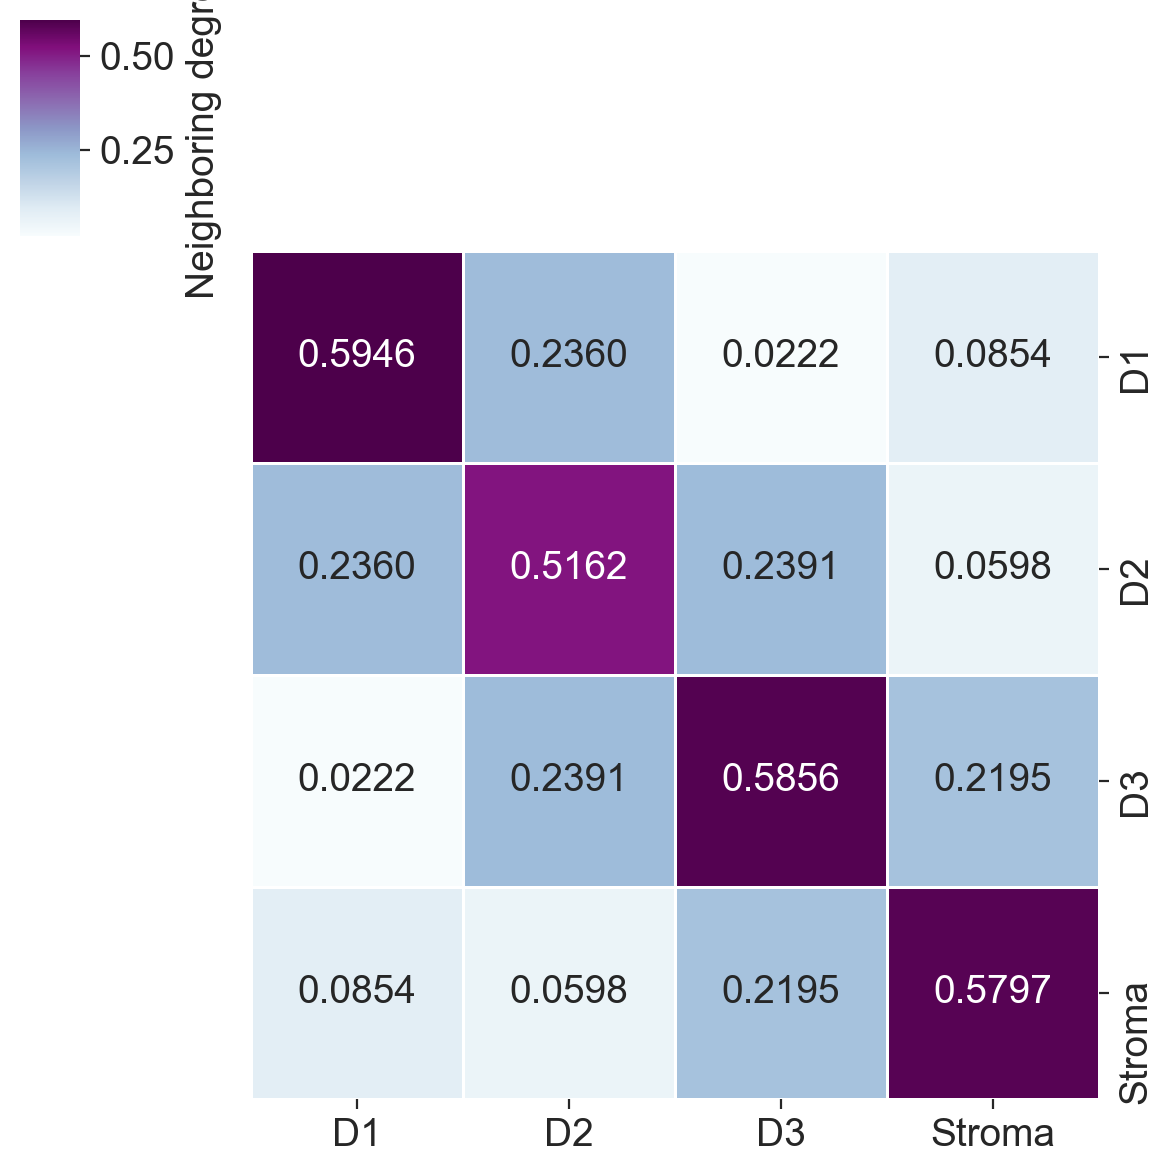

In [48]:
sns.clustermap(colocolization_df, cmap='BuPu', linewidth=0.5, linecolor='white',
                     figsize=[6,6], method='ward',row_linkage=None, col_linkage=None,
                           row_cluster=False, col_cluster=False,annot=True, fmt=".4f",
               cbar_kws={'label': 'Neighboring degree'}
                          )
plt.savefig('./Heatmap_niche_and_niche_neighborhood_averge_cross_samples.pdf', dpi=300)